In [1]:
from mne import SourceEstimate
import helper_functions as hf
import mne
import os.path as op
import numpy as np



In [2]:
#load data

ss = hf.settings_dict()
subject = 1
raw_fname = op.join(ss['raw_dir'], ss['raw_path1_list'][subject])

raw = mne.io.read_raw_fif(raw_fname, preload=True)



Opening raw data file ./raw/0002/20180522_000000/MEG/001.s2/files/s2.fif...
    Read a total of 13 projection items:
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
    Range : 93000 ... 1274999 =     46.500 ...   637.500 secs
Ready.
Reading 0 ... 1181999  =      0.000 ...   591.000 secs...


/tmp/ipykernel_32370/3628438369.py:7: RuntimeWarning: This filename (./raw/0002/20180522_000000/MEG/001.s2/files/s2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_fname, preload=True)


In [3]:
print(raw.info)

<Info | 24 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: []
 ch_names: EMG001, EMG002, EOG003, EOG004, EMG005, IASX+, IASX-, IASY+, ...
 chs: 3 EMG, 2 EOG, 11 Internal Active Shielding data (Triux systems), 102 Magnetometers, 204 Gradiometers, 1 misc, 1 Stimulus, 1 System status channel information (Triux systems)
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 139 items (3 Cardinal, 4 HPI, 132 Extra)
 events: 1 item (list)
 experimenter: Marie Louise Holm Moller (marielouise)
 file_id: 4 items (dict)
 gantry_angle: 68.0
 highpass: 0.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 50.0
 lowpass: 650.0 Hz
 meas_date: 2018-05-22 10:47:18 UTC
 meas_id: 4 items (dict)
 nchan: 325
 proj_id: 52
 proj_name: flicker
 projs: generated with autossp-1.2.0: off, generated with autossp-1.2.0: ...
 sfreq: 2000.0 Hz
 subject_info:

Using matplotlib as 2D backend.


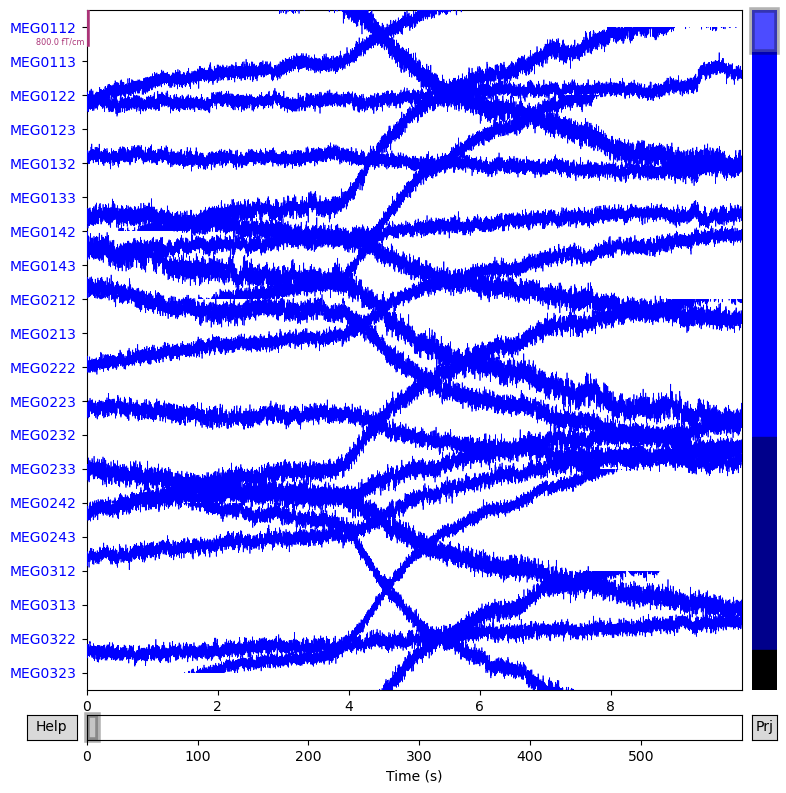

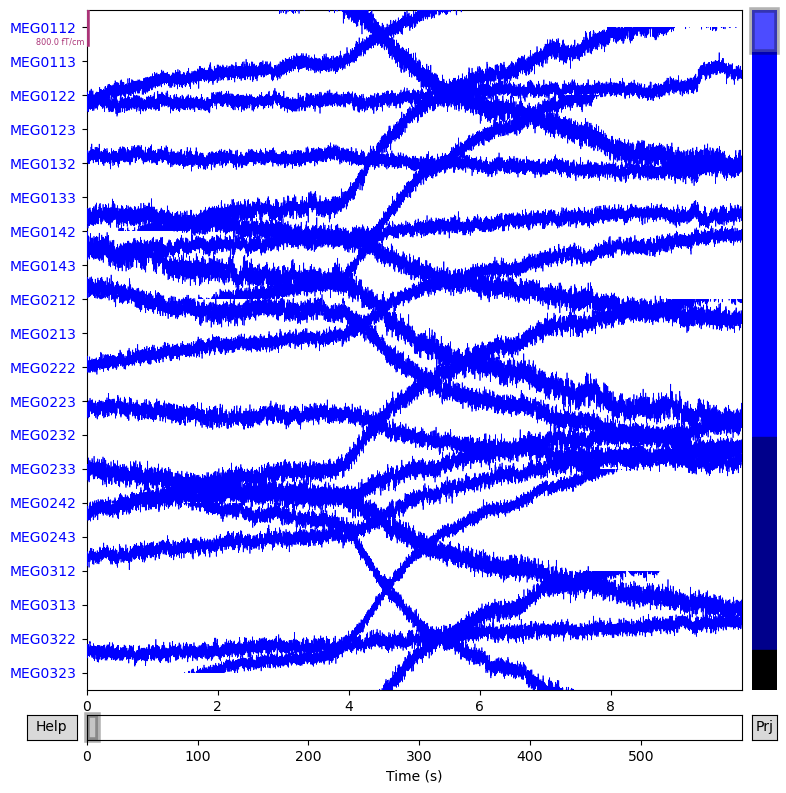

In [4]:
#inspect for bad channels
#%matplotlib qt
raw.plot(block=True)

In [5]:
#exclude bad channels (MEG1143)
raw_filtered = raw.copy()
raw_filtered.info['bads'] = ss['bads']
raw_filtered.set_channel_types(mapping={'MISC001': 'misc'})
raw_filtered.pick(picks=['grad', 'stim', 'misc'])


del(raw)
#this was done in the original pre-processing
# raw.set_channel_types(mapping={'EMG001': 'eeg'})
# raw.set_channel_types(mapping={'EMG002': 'eeg'})
# raw.set_channel_types(mapping={'EOG003': 'eeg'})
# raw.set_channel_types(mapping={'EOG004': 'eeg'})
# raw.set_channel_types(mapping={'EMG005': 'eeg'})
# raw.set_channel_types(mapping={'MISC001': 'eeg'})

/tmp/ipykernel_32370/3661418948.py:4: RuntimeWarning: The unit for channel(s) MISC001 has changed from V to NA.
  raw_filtered.set_channel_types(mapping={'MISC001': 'misc'})


Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/home/elias/miniconda3/envs/iliasgdk_thesis/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


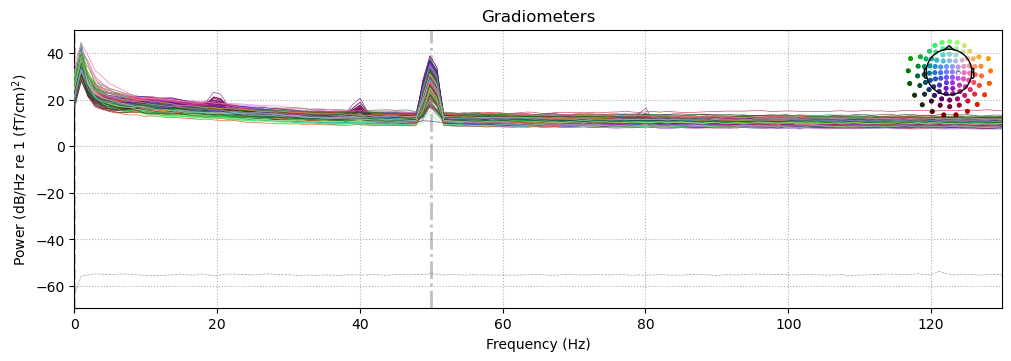

In [6]:
#plot signal power for each frequency
raw_filtered.compute_psd(fmax=130).plot()

In [7]:
#filter 35 - 45 Hz


raw_filtered.filter(l_freq=35.0, h_freq=45.0, h_trans_bandwidth=1.0)

print(raw_filtered.info)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 35 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 35.00
- Lower transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 30.62 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 45.50 Hz)
- Filter length: 6601 samples (3.300 s)

<Info | 25 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: 1 items (MEG1143)
 ch_names: MEG0112, MEG0113, MEG0122, MEG0123, MEG0132, MEG0133, MEG0142, ...
 chs: 204 Gradiometers, 1 misc, 1 Stimulus
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 139 items (3 Cardinal, 4 HPI, 132 Extra)
 events: 1 item (list)
 experim

Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/home/elias/miniconda3/envs/iliasgdk_thesis/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


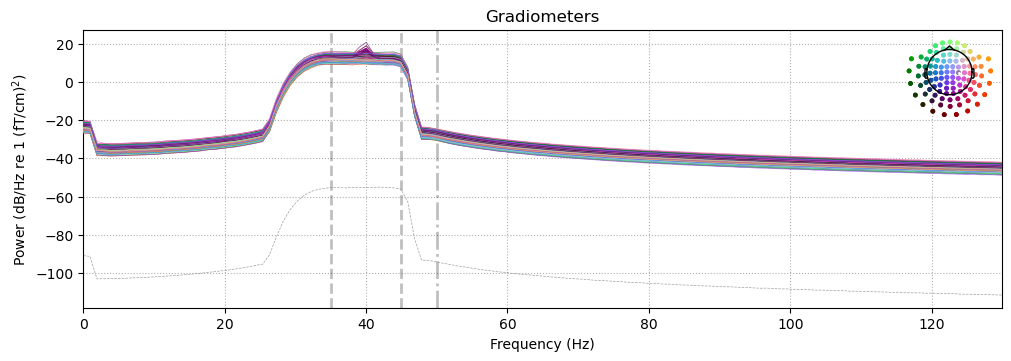

In [8]:
#plot signal power for each frequency
raw_filtered.compute_psd(fmax=130).plot()

In [9]:
#cut data into epochs
tmin = -0.5
tmax = 4.5

# events = mne.find_events(raw_filtered)
events_fname = op.join(ss['events_dir'], '0002_TCZ' + '-eve.fif')
event_id_list =  ss['event_id_list']

#events = mne.find_events(raw_filtered)
events = mne.read_events(events_fname)

epochs = mne.Epochs(raw_filtered, events, 4, tmin=tmin, tmax=tmax, preload=True)

del(raw_filtered)



Not setting metadata
10 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 10 events and 10001 original time points ...
0 bad epochs dropped


/tmp/ipykernel_32370/638307738.py:12: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  epochs = mne.Epochs(raw_filtered, events, 4, tmin=tmin, tmax=tmax, preload=True)


In [10]:
#check that all trials are present
print(epochs.get_data().shape)
print(epochs.info)

(10, 206, 10001)
<Info | 25 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: 1 items (MEG1143)
 ch_names: MEG0112, MEG0113, MEG0122, MEG0123, MEG0132, MEG0133, MEG0142, ...
 chs: 204 Gradiometers, 1 misc, 1 Stimulus
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 139 items (3 Cardinal, 4 HPI, 132 Extra)
 events: 1 item (list)
 experimenter: Marie Louise Holm Moller (marielouise)
 file_id: 4 items (dict)
 gantry_angle: 68.0
 highpass: 35.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 50.0
 lowpass: 45.0 Hz
 meas_date: 2018-05-22 10:47:18 UTC
 meas_id: 4 items (dict)
 nchan: 206
 proj_id: 52
 proj_name: flicker
 projs: generated with autossp-1.2.0: on, generated with autossp-1.2.0: ...
 sfreq: 2000.0 Hz
 subject_info: <subject_info | id: 1641, last_name: 0002, first_name: TCZ, birthday: 1978-09-13, sex: 1, hand: 1>
>


/home/elias/miniconda3/envs/iliasgdk_thesis/lib/python3.13/site-packages/matplotlib_inline/backend_inline.py:26: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))


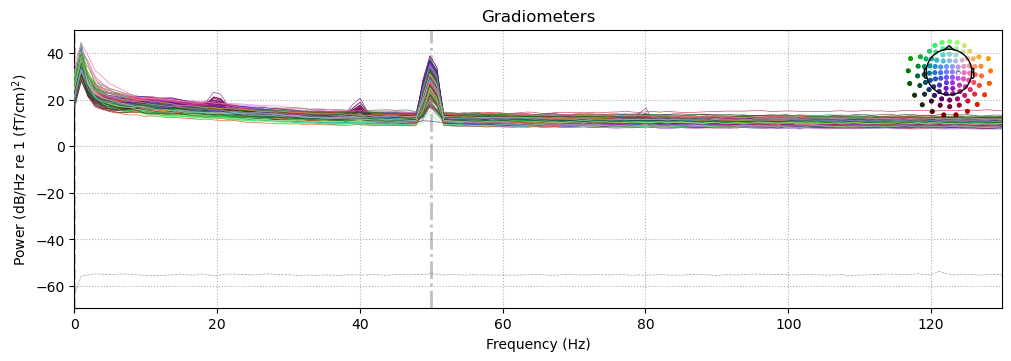

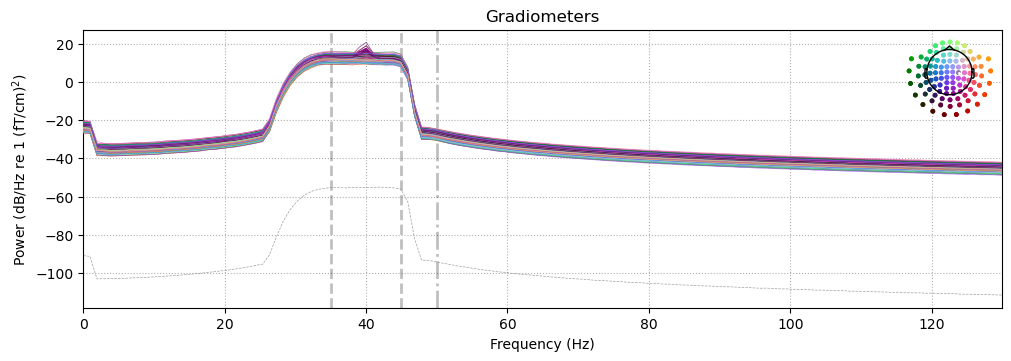

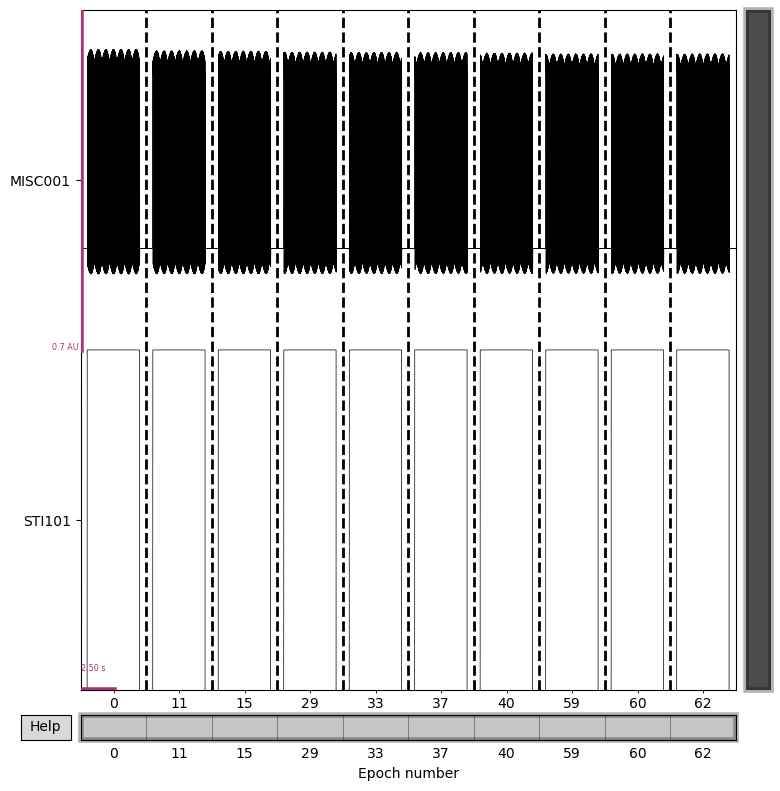

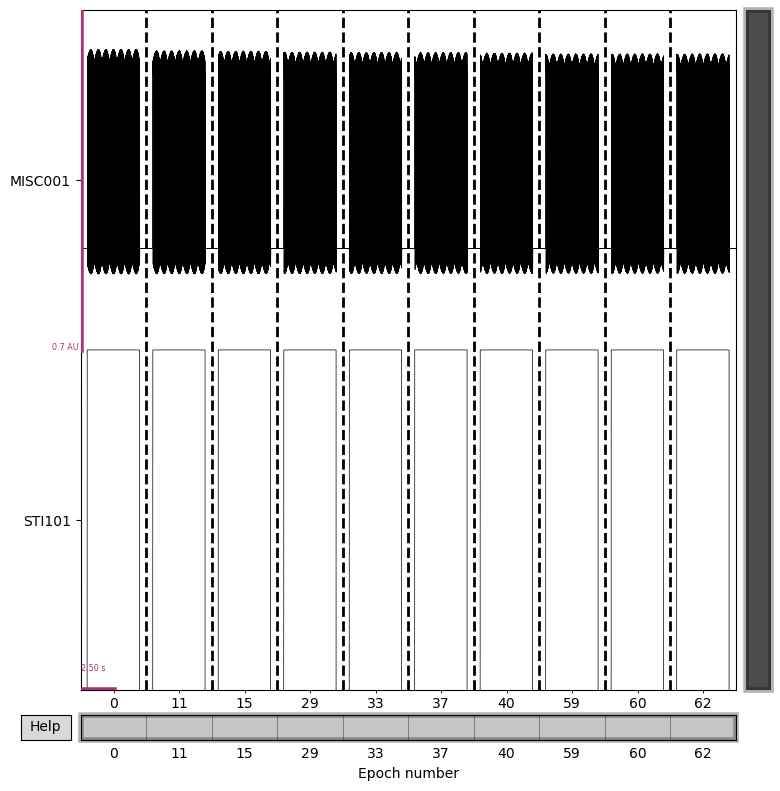

In [11]:
epochs.plot(picks=['stim', 'misc'])

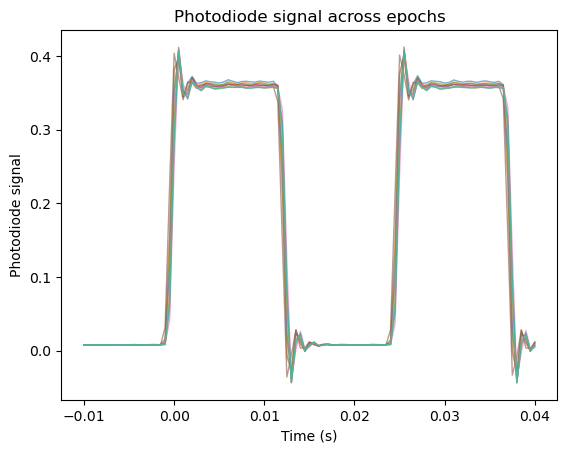

In [12]:
# inspect epoch alignment
import matplotlib.pyplot as plt

# extract misc channel
diode_epochs = epochs.copy().crop(-0.01, 0.04).pick('misc').get_data()

# remove channel dimension
diode_epochs = diode_epochs[:, 0, :]   # (n_epochs, n_times)

times = epochs.copy().crop(-0.01, 0.04).times

plt.figure()

for ep in diode_epochs:
    plt.plot(times, ep, linewidth=1, alpha=0.6)

plt.xlabel("Time (s)")
plt.ylabel("Photodiode signal")
plt.title("Photodiode signal across epochs")
plt.show()

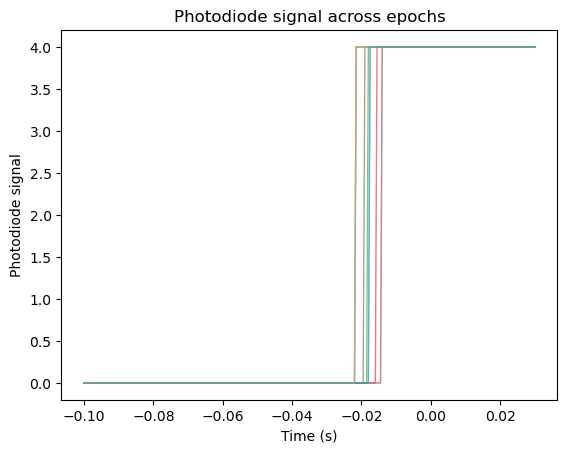

In [13]:
# inspect epoch alignment

# extract misc channel
diode_epochs = epochs.copy().crop(-0.1,0.03).pick('stim').get_data()

# remove channel dimension
diode_epochs = diode_epochs[:, 0, :]   # (n_epochs, n_times)

times = epochs.copy().crop(-0.1,0.03).times

plt.figure()

for ep in diode_epochs:
    plt.plot(times, ep, linewidth=1, alpha=0.6)

plt.xlabel("Time (s)")
plt.ylabel("Photodiode signal")
plt.title("Photodiode signal across epochs")
plt.show()

In [14]:
#average
evoked = epochs.copy().average()
evoked.pick('grad')


<Evoked | '4' (average, N=10), -0.5 – 4.5 s, baseline -0.5 – 0 s, 204 ch, ~20.7 MiB>

In [15]:
#Load forward model (later I should probably make it from scratch)
fwd_fname = op.join(ss['fwd_dir'], '0002_TCZ-fwd.fif')
fwd = mne.read_forward_solution(fwd_fname)


Reading forward solution from /home/elias/Documents/masters/Thesis/iliasgdk_thesis/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


In [16]:
from mne.beamformer import make_lcmv, apply_lcmv_epochs

#Source localization

data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=tmax)

filter = make_lcmv(
    evoked.info,
    fwd,
    data_cov=data_cov,
    reg=0.05,
    pick_ori='max-power',
    weight_norm='nai'
)


stc = mne.beamformer.apply_lcmv(evoked, filter)

/tmp/ipykernel_32370/3191266286.py:5: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=tmax)


    Created an SSP operator (subspace dimension = 5)
    Setting small GRAD eigenvalues to zero (without PCA)


/tmp/ipykernel_32370/3191266286.py:5: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=tmax)


Reducing data rank from 203 -> 198
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 89810
[done]
Computing rank from covariance with rank='info'
    GRAD: rank 198 after 5 projectors applied to 203 channels
Computing rank from covariance with rank='info'
    GRAD: rank 198 after 5 projectors applied to 203 channels
Making LCMV beamformer with rank {'grad': 198}
Computing inverse operator with 203 channels.
    203 out of 306 channels remain after picking
Selected 203 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 5)
Computing rank from covariance with rank={'grad': 198}


/tmp/ipykernel_32370/3191266286.py:7: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filter = make_lcmv(
/tmp/ipykernel_32370/3191266286.py:7: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_ra

    Setting small GRAD eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 1868 sources


/tmp/ipykernel_32370/3191266286.py:7: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filter = make_lcmv(
/tmp/ipykernel_32370/3191266286.py:7: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_ra

Filter computation complete


/tmp/ipykernel_32370/3191266286.py:17: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  stc = mne.beamformer.apply_lcmv(evoked, filter)


Showing: t = 3.113 s, (9.1, -60.0, 49.6) mm, [9, 4, 11] vox, 4239 vertex
Using control points [1.31591157 1.44221816 2.30276626]


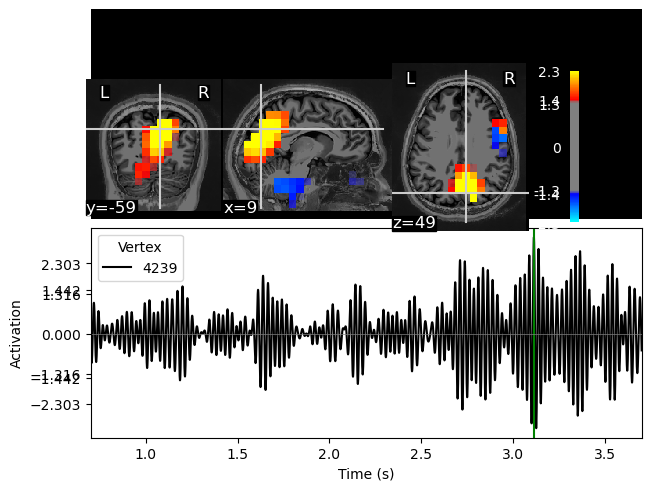

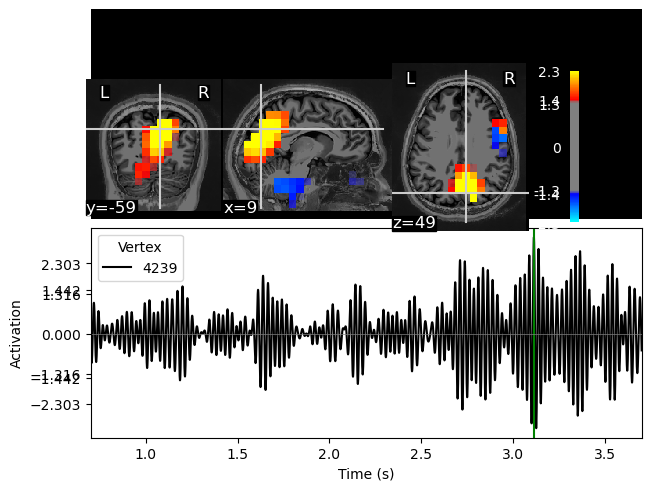

In [17]:

subject = "fs_0002_TCZ"            # or your subject ID
subjects_dir = "./scratch/fs_subjects_dir"

src = fwd['src']

stc.copy().crop(0.7,3.7).plot(src= src,subject=subject,subjects_dir=subjects_dir)

In [18]:
# find voxels with strong activation

activation_threshold_percent = 80

target_tmin = 0.7
target_tmax = 3.7

target_stc = stc.copy().crop(target_tmin, target_tmax)

max_amp = np.max(np.abs(target_stc.data), axis=1)

threshold = np.percentile(max_amp, activation_threshold_percent)

mask = max_amp > threshold

active_voxel_count = np.sum(mask)
print("active_voxel_count: ", active_voxel_count)
print("total voxel count: ", len(mask))

active_voxel_count:  374
total voxel count:  1868


Fixing initial time: 1.0 s
Showing: t = 1.000 s, (9.1, -30.0, 59.6) mm, [9, 7, 12] vox, 4671 vertex


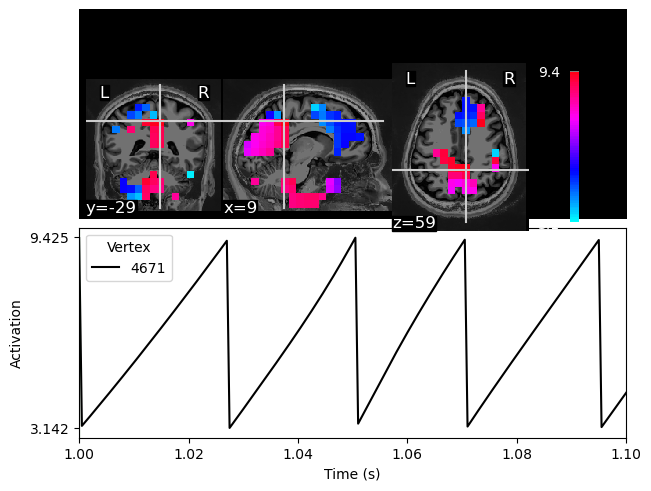

In [21]:
%matplotlib qt
import numpy as np
from scipy.signal import hilbert

# 2 analytic signal
analytic_signal = hilbert(target_stc.data, axis=1)

# 3 amplitude and phase
phase = np.angle(analytic_signal).astype(float)
#amplitude = np.abs(analytic_signal)

phase_shifted = phase + 2*np.pi

phase_masked = phase_shifted.copy()

phase_masked[~mask, :] = 0

# 6 create STC
phase_stc = target_stc.copy()
phase_stc.data = phase_masked

# 7 plot
phase_stc.copy().crop(1.0,1.1).plot(src=src, subjects_dir=subjects_dir, initial_time=1.0, colormap="hsv", clim=dict(kind="value", lims=[np.pi, np.pi, 3*np.pi]))